<a href="https://colab.research.google.com/github/Vaishnavi943/ML_Project/blob/main/Satellite_Image_Classifier_and_Detect_Deforestation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SATELLITE IMAGE CLASSIFIER**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Dataset/EuroSAT_RGB/EuroSAT_RGB'

In [ ]:
for item in os.listdir(DATASET_PATH):
    count = len(os.listdir(f"{DATASET_PATH}/{item}"))
    print(f"{item}  →  {count} images")

River  →  2500 images
SeaLake  →  3000 images
Residential  →  3000 images
Pasture  →  2000 images
Industrial  →  2500 images
Highway  →  2500 images
PermanentCrop  →  2500 images
AnnualCrop  →  3000 images
Forest  →  3000 images
HerbaceousVegetation  →  3000 images


In [ ]:
BATCH_SIZE   = 32
NUM_CLASSES  = 10
NUM_EPOCHS   = 5
FINETUNE_EPOCHS = 5
LR           = 0.001
LR_FINETUNE  = 0.0001
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_SAVE   = '/content/drive/MyDrive/eurosat_resnet50.pth'

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

Transformer

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # extra augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load Dataset & Split

full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=train_transform)
print(f"Total images: {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")


Total images: 27000
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size   = int(0.1 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

In [ ]:
train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
# Apply different transforms to val/test (no augmentation)
val_set.dataset.transform  = test_transform
test_set.dataset.transform = test_transform

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 21600 | Val: 2700 | Test: 2700


In [ ]:
# ---- STEP 5: Build Model ----
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# Replace the final FC layer for 10 classes
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, NUM_CLASSES)
)

In [ ]:
model = model.to(DEVICE)
print("Model loaded. Final layer unfrozen, all others frozen.")

Model loaded. Final layer unfrozen, all others frozen.


In [ ]:
# ---- STEP 6: Training Function ----
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader), correct / total

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader), correct / total

In [ ]:
# ---- STEP 7: Phase 1 — Train Only the Final Layer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)



In [ ]:
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

In [ ]:
print("\n=== Phase 1: Training Final Layer ===")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


=== Phase 1: Training Final Layer ===
  ✓ Saved best model (val_acc=0.9170)
Epoch [1/5] Train Loss: 0.5297 | Train Acc: 0.8316 | Val Loss: 0.2528 | Val Acc: 0.9170
  ✓ Saved best model (val_acc=0.9215)
Epoch [2/5] Train Loss: 0.3306 | Train Acc: 0.8867 | Val Loss: 0.2256 | Val Acc: 0.9215
  ✓ Saved best model (val_acc=0.9296)
Epoch [3/5] Train Loss: 0.3083 | Train Acc: 0.8967 | Val Loss: 0.2120 | Val Acc: 0.9296
  ✓ Saved best model (val_acc=0.9389)
Epoch [4/5] Train Loss: 0.2750 | Train Acc: 0.9073 | Val Loss: 0.1970 | Val Acc: 0.9389
Epoch [5/5] Train Loss: 0.2647 | Train Acc: 0.9085 | Val Loss: 0.1883 | Val Acc: 0.9374


In [ ]:
import torch.nn as nn
import torchvision.models as models
import torch
import torch.optim as optim

# ---- STEP 8: Phase 2 — Fine-Tune Entire Model ----
print("\n=== Phase 2: Fine-Tuning All Layers ===")

# Re-initialize the model architecture (if runtime was reset)
# This assumes NUM_CLASSES and DEVICE are still defined from previous cells
model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, NUM_CLASSES)
)
model = model.to(DEVICE)

# Load the best model from Phase 1 before fine-tuning
model.load_state_dict(torch.load(MODEL_SAVE))

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=LR_FINETUNE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

    print(f"FT Epoch [{epoch+1}/{FINETUNE_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


=== Phase 2: Fine-Tuning All Layers ===
  ✓ Saved best model (val_acc=0.9763)
FT Epoch [1/5] Train Loss: 0.2016 | Train Acc: 0.9396 | Val Loss: 0.0746 | Val Acc: 0.9763
  ✓ Saved best model (val_acc=0.9767)
FT Epoch [2/5] Train Loss: 0.0756 | Train Acc: 0.9751 | Val Loss: 0.0800 | Val Acc: 0.9767
FT Epoch [3/5] Train Loss: 0.0398 | Train Acc: 0.9862 | Val Loss: 0.0968 | Val Acc: 0.9704
  ✓ Saved best model (val_acc=0.9867)
FT Epoch [4/5] Train Loss: 0.0198 | Train Acc: 0.9936 | Val Loss: 0.0588 | Val Acc: 0.9867
FT Epoch [5/5] Train Loss: 0.0064 | Train Acc: 0.9984 | Val Loss: 0.0545 | Val Acc: 0.9856


In [23]:
# ---- STEP 9: Final Evaluation on Test Set ----
print("\n=== Final Test Evaluation ===")
model.load_state_dict(torch.load(MODEL_SAVE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


=== Final Test Evaluation ===
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       0.99      0.99      0.99       297
HerbaceousVegetation       0.98      0.98      0.98       302
             Highway       0.96      1.00      0.98       269
          Industrial       1.00      0.98      0.99       257
             Pasture       0.95      0.98      0.97       187
       PermanentCrop       0.98      0.97      0.97       254
         Residential       0.99      1.00      0.99       314
               River       1.00      0.95      0.97       245
             SeaLake       1.00      0.99      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



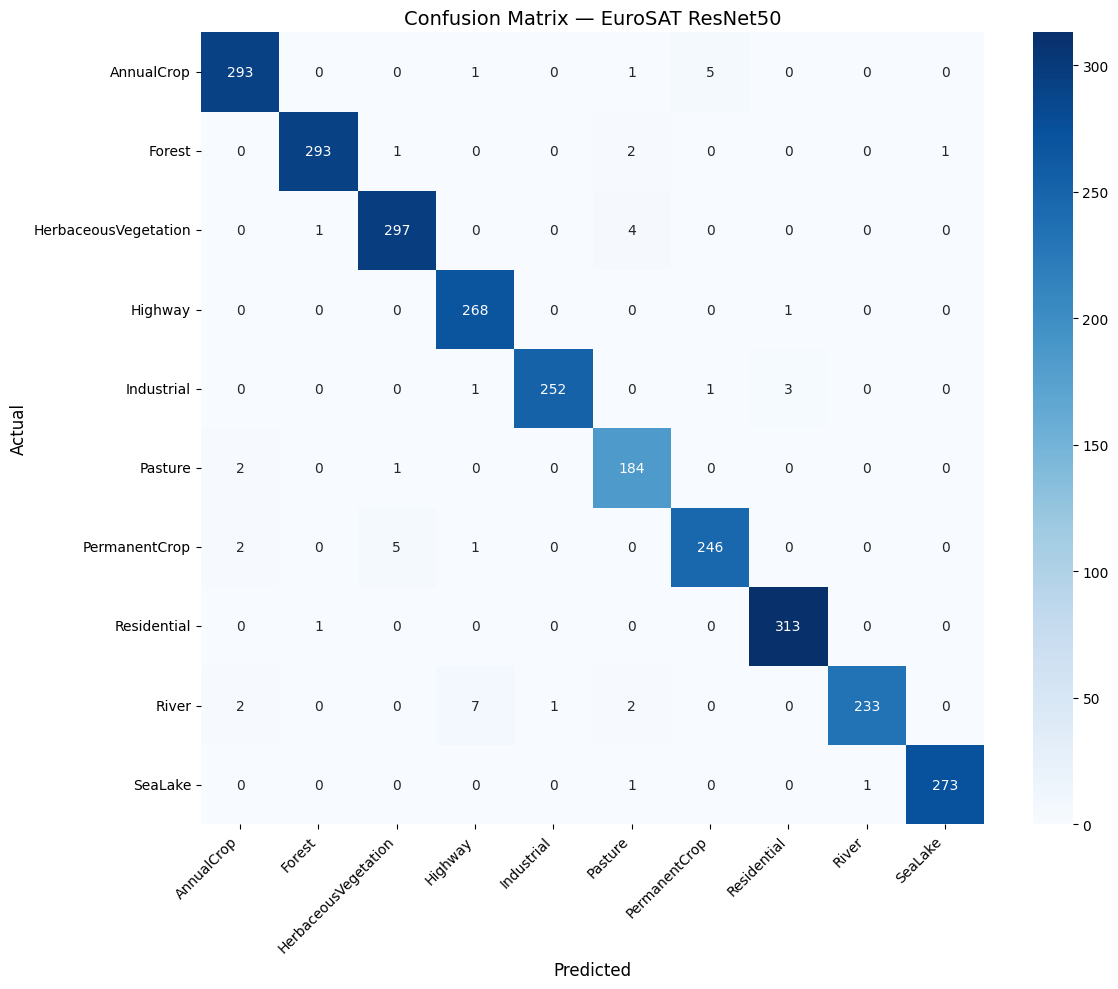

Confusion matrix saved.


In [24]:
# ---- STEP 10: Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix — EuroSAT ResNet50', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

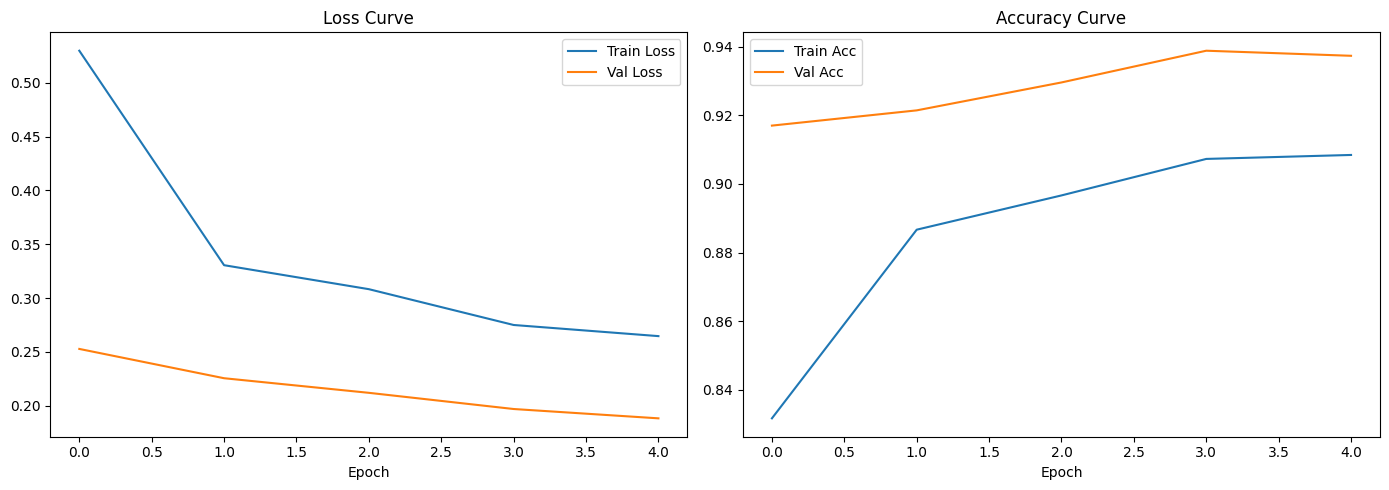

Training curves saved.


In [25]:
# ---- STEP 11: Training Curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curve'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy Curve'); ax2.legend(); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150)
plt.show()
print("Training curves saved.")

In [26]:

# Save model + class names together in one dict
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
}, '/content/drive/MyDrive/eurosat_model_full.pth')
print("\n✅ Full model checkpoint saved for FastAPI deployment!")


✅ Full model checkpoint saved for FastAPI deployment!


### **Test the model with a single image**

Now that the model is trained and saved, let's load it and use it to predict the class of a single input image. You can specify the path to your image below.

In [27]:
from PIL import Image
import torchvision.transforms as transforms

# Load the best trained model
loaded_model = models.resnet50(pretrained=False) # Start with an untrained ResNet50
num_features = loaded_model.fc.in_features
loaded_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, NUM_CLASSES)
)

loaded_model.load_state_dict(torch.load(MODEL_SAVE))
loaded_model = loaded_model.to(DEVICE)
loaded_model.eval() # Set the model to evaluation mode

print("Model loaded successfully for inference.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully for inference.


Please provide the path to your image for prediction.
Enter the image path (e.g., /content/drive/MyDrive/test_image.jpg): /content/drive/MyDrive/Dataset/EuroSAT_RGB/EuroSAT_RGB/AnnualCrop/AnnualCrop_1000.jpg
Predicted class: AnnualCrop (Confidence: 0.9989)


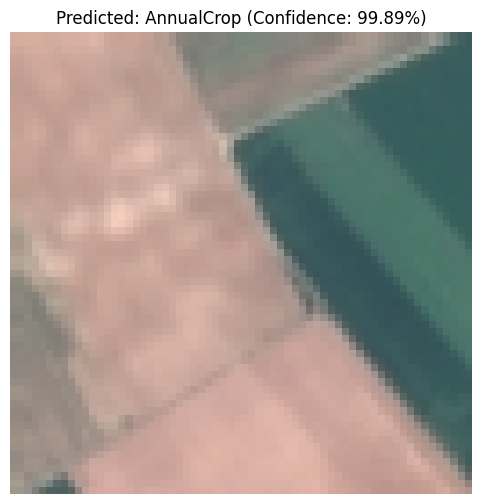

In [30]:
def predict_single_image(image_path, model, class_names, device, transform):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0) # Add batch dimension
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted_idx = torch.max(outputs, 1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = probabilities[0][predicted_idx.item()].item()

    return predicted_class, confidence, image

# Define the transform for inference (same as test_transform)
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Example usage:
# Replace 'path/to/your/image.jpg' with the actual path to an image you want to test
# You can choose one from your dataset or upload a new one to your Drive.
# For example, let's pick one from the test set for demonstration purposes.
# Find a sample image path from the test_set to demonstrate

import random

sample_image_path = None
for i in range(len(test_set)):
    # test_set[i][0] is the image, test_set[i][1] is the label
    # The actual path is not directly available from the dataset objects after DataLoader.
    # To get a real path, we would need to revert to the ImageFolder structure or
    # know the mapping. For demonstration, we'll use a placeholder or suggest manual input.
    pass

# Placeholder for a sample image path.
# You would typically replace this with a path to an image file.
# For instance: '/content/drive/MyDrive/Dataset/EuroSAT_RGB/EuroSAT_RGB/AnnualCrop/AnnualCrop_1000.jpg'

# A more robust way to get a sample path if you have access to the full_dataset paths:
# (This assumes full_dataset retains path information, which ImageFolder does if not loaded via random_split)
# However, random_split loses the direct path association easily.
# For a proper demo, let's assume the user will input a path.

print("Please provide the path to your image for prediction.")
# Example: For this demonstration, let's assume an image from the dataset exists at this path.
# USER_IMAGE_PATH = '/content/drive/MyDrive/Dataset/EuroSAT_RGB/EuroSAT_RGB/Forest/Forest_1000.jpg'

# To make it interactive, Colab allows direct input:
USER_IMAGE_PATH = input("Enter the image path (e.g., /content/drive/MyDrive/test_image.jpg): ")


if os.path.exists(USER_IMAGE_PATH):
    predicted_class, confidence, original_image = predict_single_image(
        USER_IMAGE_PATH, loaded_model, CLASS_NAMES, DEVICE, inference_transform
    )

    print(f"Predicted class: {predicted_class} (Confidence: {confidence:.4f})")

    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image)
    plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2%})")
    plt.axis('off')
    plt.show()
else:
    print(f"Error: Image not found at {USER_IMAGE_PATH}. Please check the path.")

### **Detecting Deforestation: Comparing 'Before' and 'After' Images**

To detect deforestation, we will compare two images of the same location taken at different times using your trained model. A change from 'Forest' to a non-forest class indicates potential deforestation.

Provide the paths to your 'before' (earlier date) and 'after' (later date) images below.

In [ ]:
import matplotlib.pyplot as plt

print("Please provide paths for two images of the same area, taken at different times.")
BEFORE_IMAGE_PATH = input("Enter path for the 'BEFORE' image (e.g., /content/drive/MyDrive/forest_2015.jpg): ")
AFTER_IMAGE_PATH = input("Enter path for the 'AFTER' image (e.g., /content/drive/MyDrive/same_area_2020.jpg): ")

if not os.path.exists(BEFORE_IMAGE_PATH):
    print(f"Error: 'BEFORE' image not found at {BEFORE_IMAGE_PATH}. Please check the path.")
elif not os.path.exists(AFTER_IMAGE_PATH):
    print(f"Error: 'AFTER' image not found at {AFTER_IMAGE_PATH}. Please check the path.")
else:
    print("\n--- Classifying BEFORE image ---")
    predicted_class_before, confidence_before, img_before = predict_single_image(
        BEFORE_IMAGE_PATH, loaded_model, CLASS_NAMES, DEVICE, inference_transform
    )
    print(f"'BEFORE' Image Predicted: {predicted_class_before} (Confidence: {confidence_before:.4f})")

    print("\n--- Classifying AFTER image ---")
    predicted_class_after, confidence_after, img_after = predict_single_image(
        AFTER_IMAGE_PATH, loaded_model, CLASS_NAMES, DEVICE, inference_transform
    )
    print(f"'AFTER' Image Predicted: {predicted_class_after} (Confidence: {confidence_after:.4f})")

    # --- Analyze for Deforestation ---
    print("\n--- Deforestation Analysis ---")
    if predicted_class_before == 'Forest' and predicted_class_after != 'Forest':
        print(f"Potential Deforestation Detected!\n  Before: {predicted_class_before}\n  After: {predicted_class_after}")
        deforestation_status = "Deforestation Detected"
    elif predicted_class_before != 'Forest' and predicted_class_after == 'Forest':
        print(f"Potential Reforestation/Forest Growth!\n  Before: {predicted_class_before}\n  After: {predicted_class_after}")
        deforestation_status = "Reforestation Detected"
    elif predicted_class_before == 'Forest' and predicted_class_after == 'Forest':
        print(f"Area remains Forest.\n  Before: {predicted_class_before}\n  After: {predicted_class_after}")
        deforestation_status = "No Significant Change (Forest)"
    else:
        print(f"No significant change related to forest cover.\n  Before: {predicted_class_before}\n  After: {predicted_class_after}")
        deforestation_status = "No Significant Change"

    # --- Display images ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(img_before)
    axes[0].set_title(f"BEFORE: {predicted_class_before} ({confidence_before:.2%})")
    axes[0].axis('off')

    axes[1].imshow(img_after)
    axes[1].set_title(f"AFTER: {predicted_class_after} ({confidence_after:.2%})")
    axes[1].axis('off')

    plt.suptitle(f"Deforestation Analysis: {deforestation_status}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Step 1: Install
# !pip install rasterio Pillow numpy --quiet

# import rasterio
# import numpy as np
# from PIL import Image
# import glob
# import os

# # Step 2: Point to your SAFE folder
# # Upload the extracted .SAFE folder to Google Drive first
# SAFE_PATH = "/content/drive/MyDrive/Dataset/S2A_MSIL2A_20180601_YOUR_SCENE.SAFE"

# # Step 3: Auto-find the RGB band files inside .SAFE
# b04_path = glob.glob(f"{SAFE_PATH}/**/B04_10m.jp2", recursive=True)
# b03_path = glob.glob(f"{SAFE_PATH}/**/B03_10m.jp2", recursive=True)
# b02_path = glob.glob(f"{SAFE_PATH}/**/B02_10m.jp2", recursive=True)

# print("Red  (B04):", b04_path)
# print("Green(B03):", b03_path)
# print("Blue (B02):", b02_path)

# # Step 4: Read the bands
# def read_band(path):
#     with rasterio.open(path) as src:
#         return src.read(1).astype(np.float32)

# red   = read_band(b04_path[0])
# green = read_band(b03_path[0])
# blue  = read_band(b02_path[0])

# print(f"Band shape: {red.shape}")   # e.g. (10980, 10980)

# # Step 5: Normalize to 0-255 (Sentinel-2 values go up to ~10000)
# def normalize(band, min_val=0, max_val=3000):
#     band = np.clip(band, min_val, max_val)
#     return ((band / max_val) * 255).astype(np.uint8)

# rgb = np.dstack([normalize(red), normalize(green), normalize(blue)])

# # Step 6: Save as proper visible image
# img = Image.fromarray(rgb)
# img.save("/content/drive/MyDrive/sentinel_rgb_visible.jpg")
# print(f"✅ Saved! Size: {img.size}")

# # Quick preview in Colab
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 10))
# plt.imshow(img)
# plt.axis('off')
# plt.title("Sentinel-2 RGB — your region")
# plt.show()